# 7 · Enhancer redundancy — analysis (local)

Notebook 6 (Spark) wrote a finished redundancy table per directed comparison to S3. Pull them to `data/whole_chromosomes/enhancer_redundancy/<comparison>/`. This local notebook (no storage/model access) joins DESeq2, computes **frequency** per comparison, and compares **|log2FC|** between redundancy genes and non-redundant switchers.

Hypothesis: redundancy genes (old enhancer drifts away, a different one stays close) have smaller |log2FC| — conserved expression.

In [1]:
import os.path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

REDUNDANCY_DIR = "../../data/whole_chromosomes/enhancer_redundancy"
DESEQ_DIR = "../../data/deseq"
FIGS = "figs"; EXPORT = "export"

# comparison -> (deseq parquet, flip_log2fc?) — align sign to c1->c2 direction.
DESEQ = {
    "gm12878_vs_h1esc": ("gm12878_vs_h1esc_results.parquet", False),
    "h1esc_vs_gm12878": ("gm12878_vs_h1esc_results.parquet", True),
    "h1esc_vs_hffc6":   ("h1esc_vs_hffc6_results.parquet", False),
    "hffc6_vs_h1esc":   ("h1esc_vs_hffc6_results.parquet", True),
    "gm12878_vs_hffc6": ("gm12878_vs_hffc6_results.parquet", False),
    "hffc6_vs_gm12878": ("gm12878_vs_hffc6_results.parquet", True),
}

In [2]:
def redundancy_frequency(df):
    denom = int(df['nearest_changed'].sum())
    return float('nan') if denom == 0 else int(df['is_redundancy'].sum()) / denom

# notebook 6 computes the flags (incl. the small→large toggle), so we just read them here.
_BOOL_COLS = ['nearest_changed', 'L1_found_in_c2', 'small_to_large',
              'is_redundancy', 'is_nonredundant_switcher']

def load_comparison(comparison):
    # notebook 6 writes a portable CSV per comparison (data.csv); fall back to pickle / parquet dir
    base = os.path.join(REDUNDANCY_DIR, comparison)
    csv, pkl = os.path.join(base, "data.csv"), os.path.join(base, "data.pkl")
    if os.path.exists(csv):
        rt = pd.read_csv(csv)
        for col in _BOOL_COLS:               # CSV bools may come back as strings
            if col in rt.columns and rt[col].dtype != bool:
                rt[col] = rt[col].astype(str).str.strip().str.lower().isin(['true', '1'])
    elif os.path.exists(pkl):
        rt = pd.read_pickle(pkl)
    else:
        rt = pd.read_parquet(base)

    fname, flip = DESEQ[comparison]
    # DESeq2 parquet keys genes by the index 'Geneid' with a version suffix (ENSG....N)
    de = pd.read_parquet(os.path.join(DESEQ_DIR, fname)).reset_index()
    gid = next((c for c in ['gene_id', 'Geneid', 'index'] if c in de.columns), de.columns[0])
    de = de.rename(columns={gid: 'gene_id'})[['gene_id', 'log2FoldChange', 'padj']].copy()
    if flip:
        de['log2FoldChange'] = -de['log2FoldChange']
    de['gene_id'] = de['gene_id'].astype(str).str.split('.').str[0]
    rt['gene_id'] = rt['gene_id'].astype(str).str.split('.').str[0]
    m = rt.merge(de, on='gene_id', how='inner')
    m['abs_log2fc'] = m['log2FoldChange'].abs()
    return m

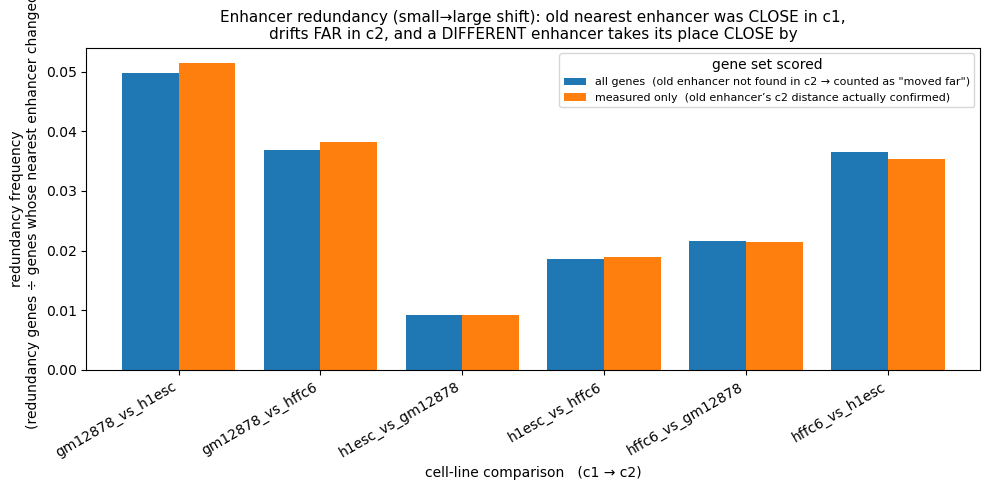

,comparison,subset,coverage,n_genes,n_changed,n_small_to_large,n_redundancy,frequency
0,gm12878_vs_h1esc,all,0.971,14327,12257,1283,610,0.049767
1,gm12878_vs_h1esc,measured_only,1.000,13915,11845,1277,609,0.051414
2,h1esc_vs_gm12878,all,1.000,14327,12257,247,112,0.009138
3,h1esc_vs_gm12878,measured_only,1.000,14327,12257,247,112,0.009138
4,h1esc_vs_hffc6,all,0.984,14129,13201,384,245,0.018559
5,h1esc_vs_hffc6,measured_only,1.000,13900,12972,384,245,0.018887
6,hffc6_vs_h1esc,all,0.999,14129,13201,977,483,0.036588
7,hffc6_vs_h1esc,measured_only,1.000,14108,13180,959,465,0.035281
8,gm12878_vs_hffc6,all,0.969,15730,14759,1085,545,0.036927
9,gm12878_vs_hffc6,measured_only,1.000,15249,14278,1083,545,0.038171


In [3]:
def summarize(m):
    return {'n_genes': len(m), 'n_changed': int(m['nearest_changed'].sum()),
            'n_small_to_large': int(m['small_to_large'].sum()),
            'n_redundancy': int(m['is_redundancy'].sum()), 'frequency': redundancy_frequency(m)}

rows = []; joined = {}
for comparison in DESEQ:
    try:
        m = load_comparison(comparison)
    except FileNotFoundError:
        print(f"skip {comparison} (no data yet)")
        continue
    joined[comparison] = m
    rows.append({**summarize(m), 'comparison': comparison, 'subset': 'all',
                 'coverage': round(float(m['L1_found_in_c2'].mean()), 3)})
    rows.append({**summarize(m[m['L1_found_in_c2']]), 'comparison': comparison,
                 'subset': 'measured_only', 'coverage': 1.0})

freq_df = pd.DataFrame(rows)[['comparison', 'subset', 'coverage',
                              'n_genes', 'n_changed', 'n_small_to_large', 'n_redundancy', 'frequency']]
freq_df.to_csv(os.path.join(EXPORT, "enhancer_redundancy_frequency.csv"), index=False)

# --- plot: enhancer redundancy = old nearest enhancer was CLOSE (small) in c1, drifts
#     FAR (large) in c2, and a DIFFERENT enhancer (new ID) is now CLOSE in c2 ---
_SUBSET_LABEL = {
    'all': 'all genes  (old enhancer not found in c2 → counted as "moved far")',
    'measured_only': 'measured only  (old enhancer’s c2 distance actually confirmed)',
}
if not freq_df.empty:
    piv = (freq_df.pivot(index='comparison', columns='subset', values='frequency')
                  .rename(columns=_SUBSET_LABEL))
    ax = piv.plot.bar(figsize=(10, 5), width=0.8)
    ax.set_title("Enhancer redundancy (small→large shift): old nearest enhancer was CLOSE in c1,\n"
                 "drifts FAR in c2, and a DIFFERENT enhancer takes its place CLOSE by", fontsize=11)
    ax.set_xlabel("cell-line comparison   (c1 → c2)")
    ax.set_ylabel("redundancy frequency\n(redundancy genes ÷ genes whose nearest enhancer changed)")
    ax.legend(title="gene set scored", fontsize=8, loc='upper right')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.savefig(os.path.join(FIGS, "exp6_frequency.png"), dpi=150, bbox_inches='tight')
    plt.show()
freq_df

In [4]:
def compare_log2fc(redundancy_lfc, no_replacement_lfc):
    # SIGNED log2FC (not |log2FC|): negative = expression went DOWN in c2.
    a = np.asarray(redundancy_lfc, dtype=float); a = a[~np.isnan(a)]
    b = np.asarray(no_replacement_lfc, dtype=float); b = b[~np.isnan(b)]
    n1, n2 = len(a), len(b)
    if n1 == 0 or n2 == 0:
        return {'n_redundancy': n1, 'n_no_replacement': n2, 'median_redundancy': np.nan,
                'median_no_replacement': np.nan, 'U': np.nan, 'pvalue': np.nan, 'rank_biserial': np.nan}
    res = stats.mannwhitneyu(a, b, alternative='two-sided')
    return {'n_redundancy': n1, 'n_no_replacement': n2,
            'median_redundancy': float(np.median(a)),
            'median_no_replacement': float(np.median(b)),
            'U': float(res.statistic), 'pvalue': float(res.pvalue),
            'rank_biserial': 1.0 - (2.0 * res.statistic) / (n1 * n2)}

# Hypothesis with signed log2FC: when the old (small→large) enhancer leaves and NOTHING
# replaces it, the gene loses enhancer support => log2FC skews NEGATIVE. When a redundant
# enhancer stays close, expression is conserved => log2FC ~ 0. So expect
#   median_no_replacement < median_redundancy   and   rank_biserial > 0.
stat_rows = []
for comparison, m in joined.items():
    for subset, mm in [('all', m), ('measured_only', m[m['L1_found_in_c2']])]:
        s = compare_log2fc(mm.loc[mm.is_redundancy, 'log2FoldChange'].values,
                           mm.loc[mm.is_nonredundant_switcher, 'log2FoldChange'].values)
        s['comparison'] = comparison; s['subset'] = subset
        stat_rows.append(s)
stats_df = pd.DataFrame(stat_rows)[['comparison', 'subset', 'n_redundancy', 'n_no_replacement',
                                    'median_redundancy', 'median_no_replacement', 'U', 'pvalue', 'rank_biserial']]
stats_df.to_csv(os.path.join(EXPORT, "enhancer_redundancy_log2fc_stats.csv"), index=False)
stats_df

,comparison,subset,n_redundancy,n_no_replacement,median_redundancy,median_no_replacement,U,pvalue,rank_biserial
0,gm12878_vs_h1esc,all,610,669,-0.070400,-0.191869,219397.0,0.019976,-0.075238
1,gm12878_vs_h1esc,measured_only,609,664,-0.070155,-0.189408,217137.0,0.022522,-0.073936
2,h1esc_vs_gm12878,all,112,128,0.079751,-0.047827,7721.0,0.303162,-0.077148
3,h1esc_vs_gm12878,measured_only,112,128,0.079751,-0.047827,7721.0,0.303162,-0.077148
4,h1esc_vs_hffc6,all,245,139,0.100727,-0.378955,19651.0,0.012094,-0.154074
5,h1esc_vs_hffc6,measured_only,245,139,0.100727,-0.378955,19651.0,0.012094,-0.154074
6,hffc6_vs_h1esc,all,483,490,0.095469,0.000321,124906.0,0.133841,-0.055529
7,hffc6_vs_h1esc,measured_only,465,490,0.098327,0.000321,120784.0,0.107446,-0.060206
8,gm12878_vs_hffc6,all,545,537,-0.135770,-0.166119,156679.0,0.044105,-0.070705
9,gm12878_vs_hffc6,measured_only,545,535,-0.135770,-0.166651,156188.5,0.042423,-0.071344


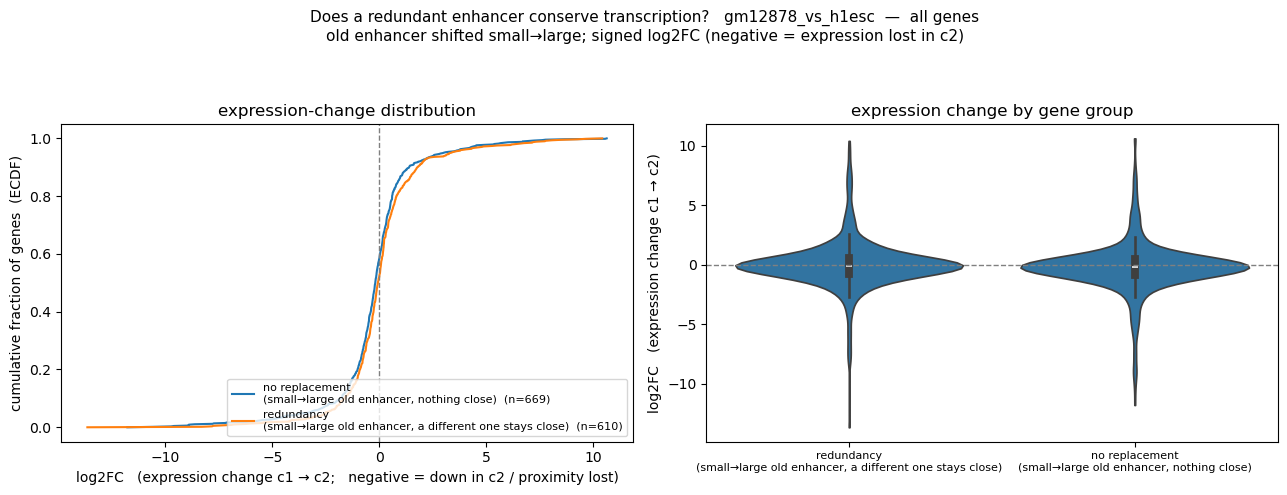

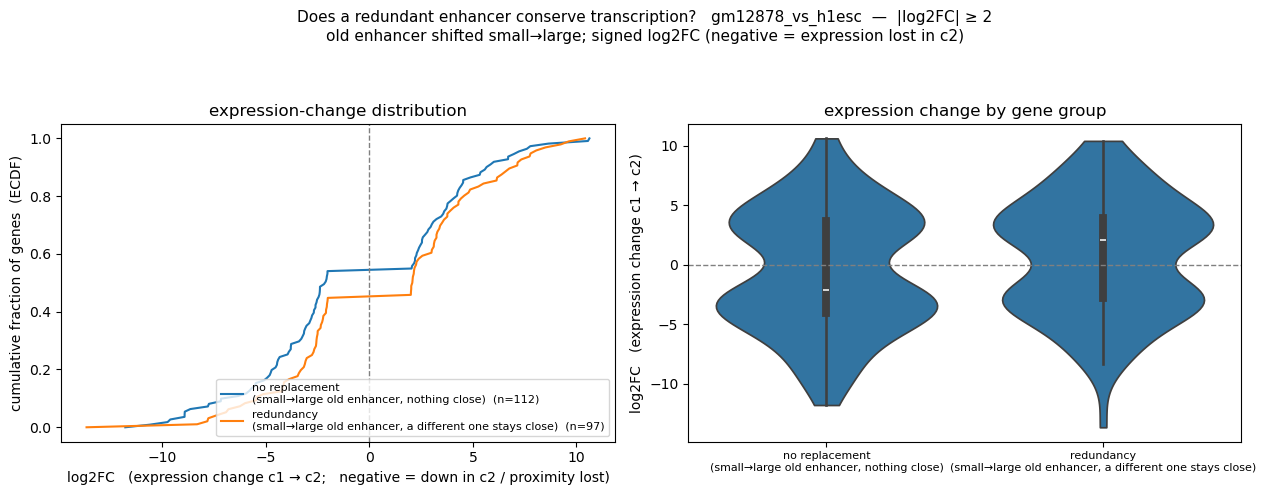

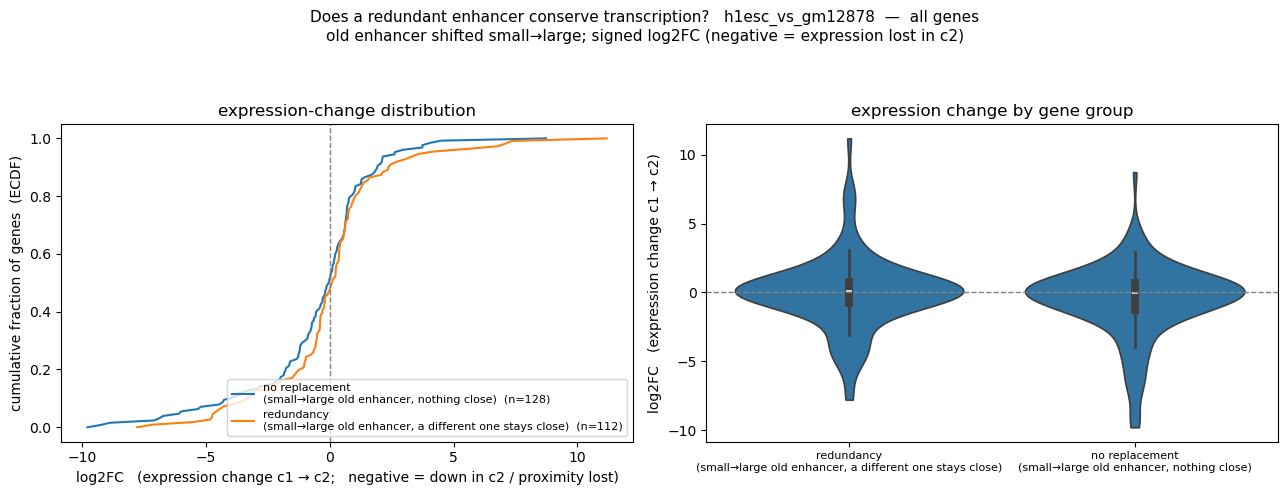

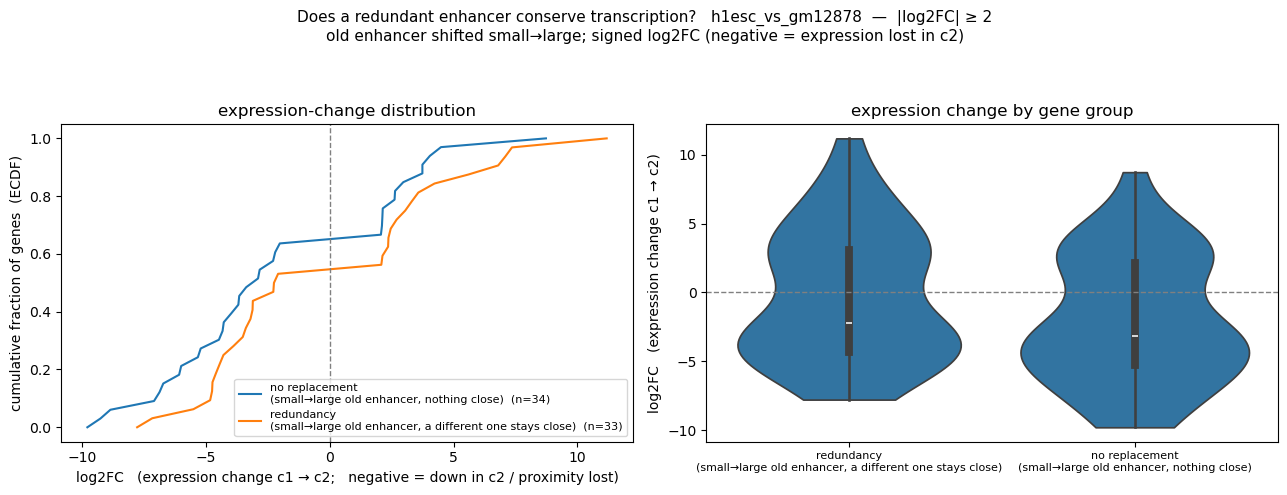

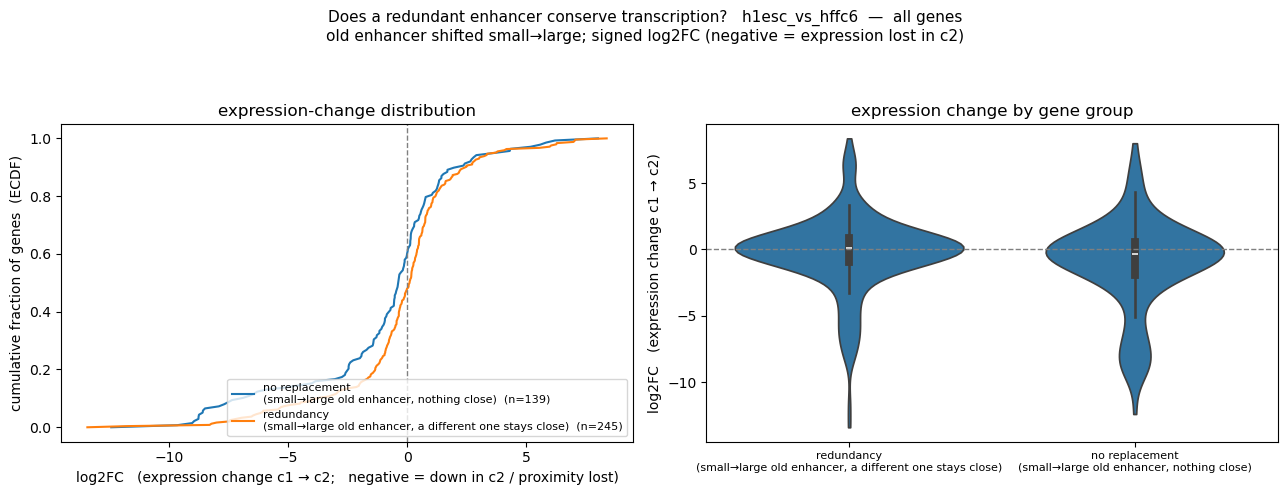

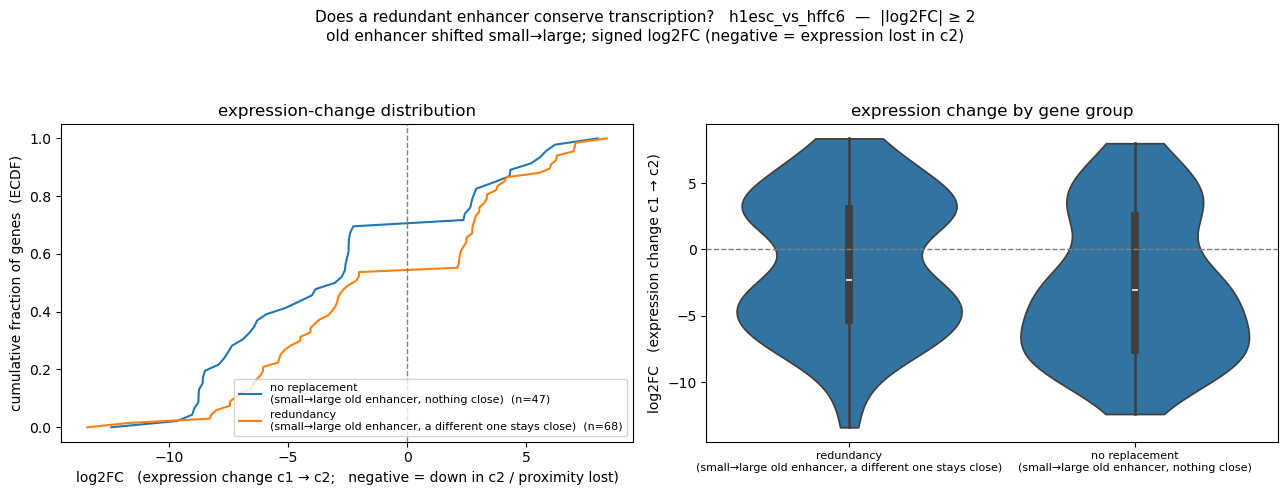

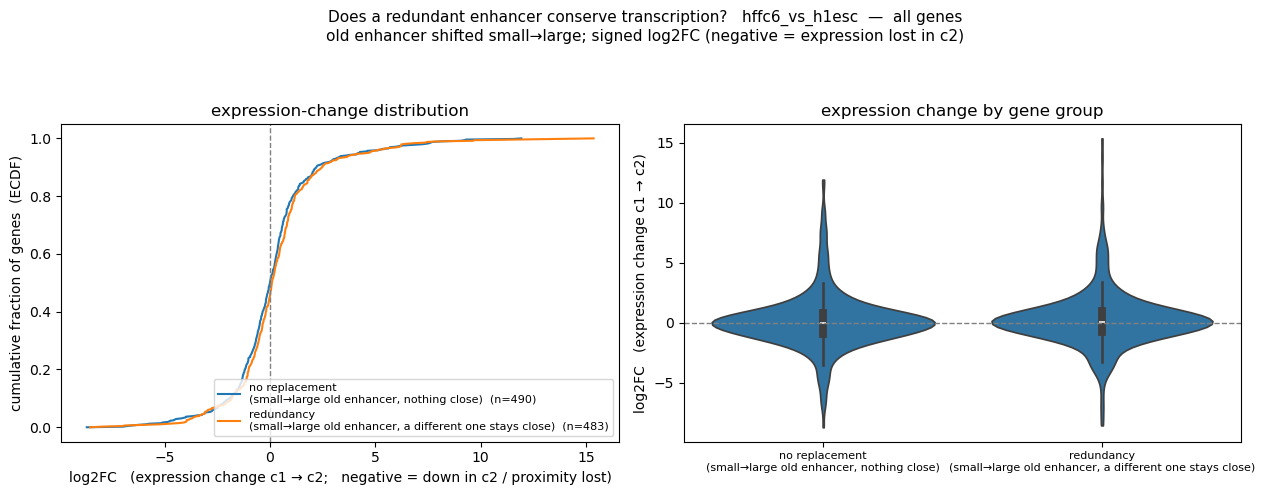

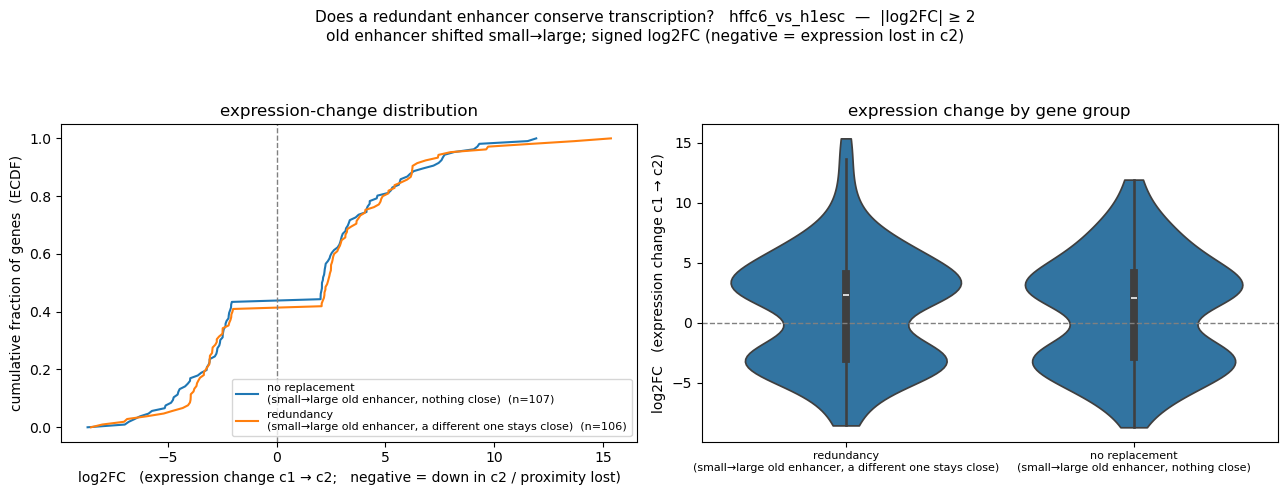

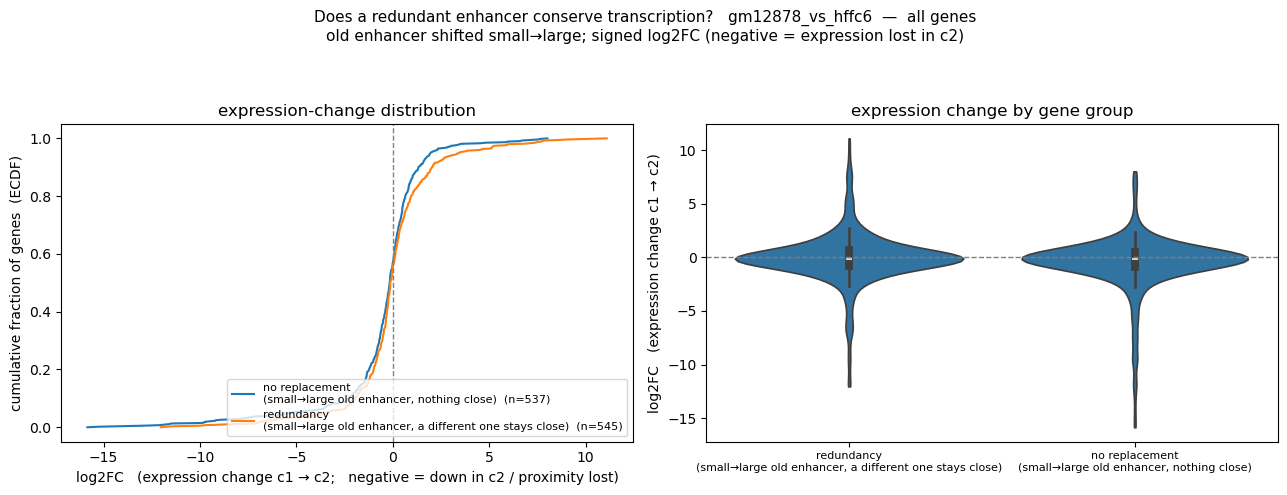

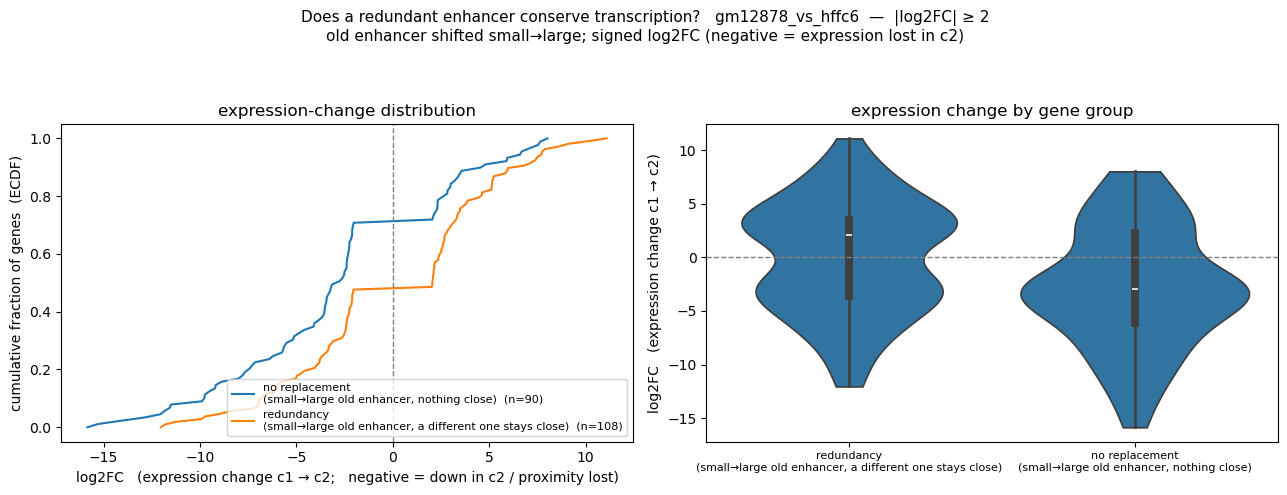

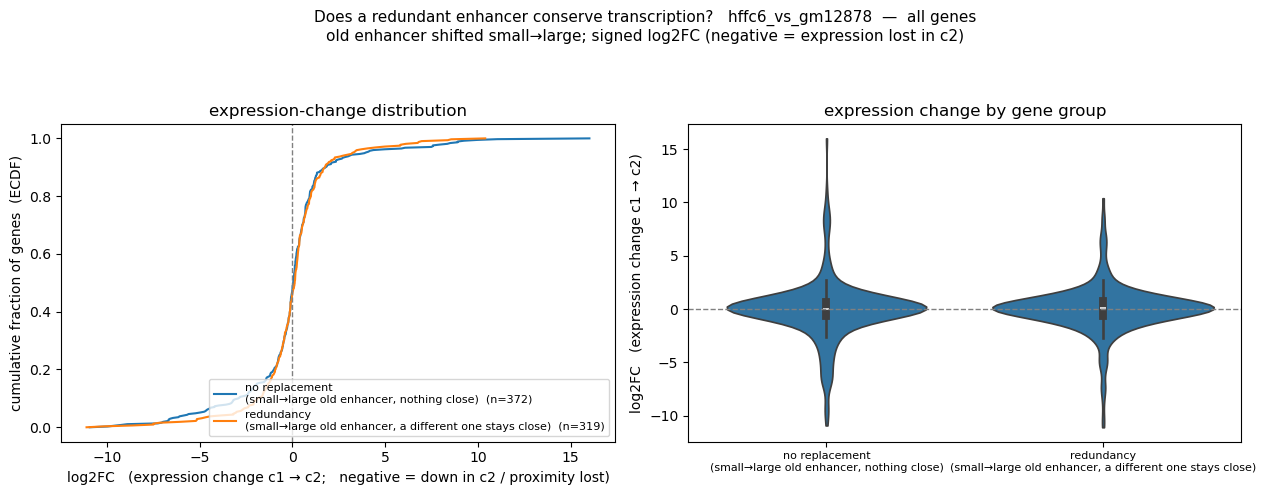

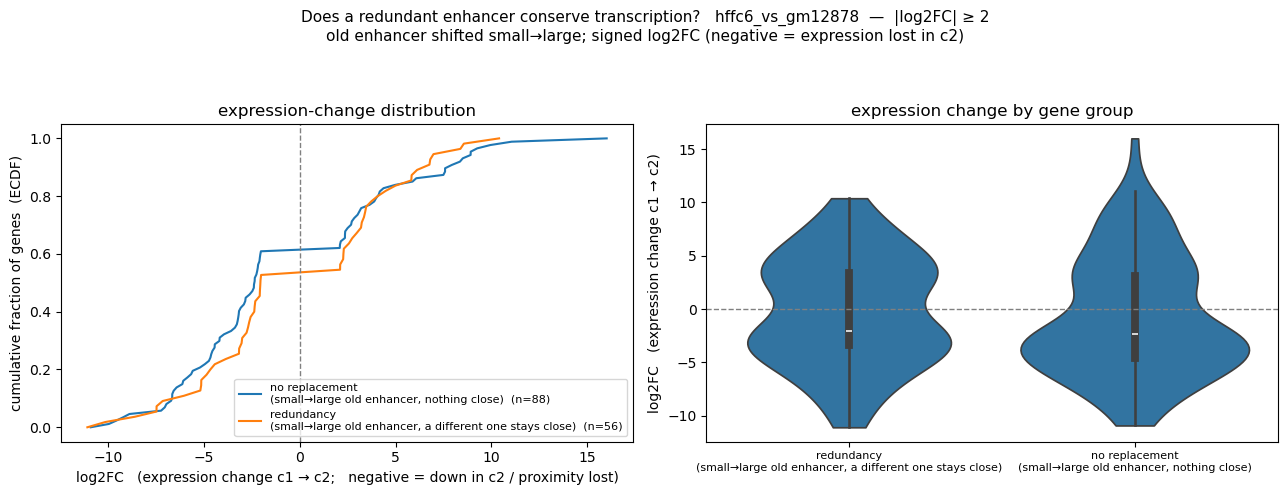

In [7]:
# --- the test, with SIGNED log2FC. Rendered for ALL genes and for significant changes only
#     (|log2FC| >= threshold). The >=2 view drops the huge ~0 pile and exposes the direction:
#     redundancy     = small→large old enhancer, a DIFFERENT one stays close -> expect ~0
#     no replacement = small→large old enhancer, nothing close               -> expect < 0
GROUP_LABEL = {
    'redundancy':    'redundancy\n(small→large old enhancer, a different one stays close)',
    'non_redundant': 'no replacement\n(small→large old enhancer, nothing close)',
}
PLOT_THRESHOLDS = [0.0, 2.0]   # all genes, then |log2FC| >= 2

for comparison, m in joined.items():
    base = m.assign(group=np.where(m.is_redundancy, 'redundancy',
                          np.where(m.is_nonredundant_switcher, 'non_redundant', None))).dropna(subset=['group'])
    if base.empty:
        continue
    for thr in PLOT_THRESHOLDS:
        sub = base[base['log2FoldChange'].abs() >= thr].copy()
        if sub.empty:
            continue
        sub['group_label'] = sub['group'].map(GROUP_LABEL)
        tag = "all genes" if thr == 0 else f"|log2FC| ≥ {thr:g}"

        fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 5))
        fig.suptitle(f"Does a redundant enhancer conserve transcription?   {comparison}  —  {tag}\n"
                     "old enhancer shifted small→large; signed log2FC (negative = expression lost in c2)",
                     fontsize=11)

        for g, gg in sub.groupby('group'):
            xs = np.sort(gg['log2FoldChange'].values)
            a1.plot(xs, np.linspace(0, 1, len(xs)), label=f"{GROUP_LABEL[g]}  (n={len(gg)})")
        a1.axvline(0, color='grey', lw=1, ls='--')
        a1.set_xlabel("log2FC   (expression change c1 → c2;   negative = down in c2 / proximity lost)")
        a1.set_ylabel("cumulative fraction of genes  (ECDF)")
        a1.set_title("expression-change distribution")
        a1.legend(fontsize=8, loc='lower right')

        sns.violinplot(data=sub, x='group_label', y='log2FoldChange', ax=a2, cut=0)
        a2.axhline(0, color='grey', lw=1, ls='--')
        a2.set_xlabel("")
        a2.set_ylabel("log2FC   (expression change c1 → c2)")
        a2.set_title("expression change by gene group")
        a2.tick_params(axis='x', labelsize=8)

        plt.tight_layout(rect=[0, 0, 1, 0.92])
        suffix = "all" if thr == 0 else f"abs{thr:g}"
        plt.savefig(os.path.join(FIGS, f"exp6_log2fc_{comparison}_{suffix}.png"), dpi=150, bbox_inches='tight')
        plt.show()

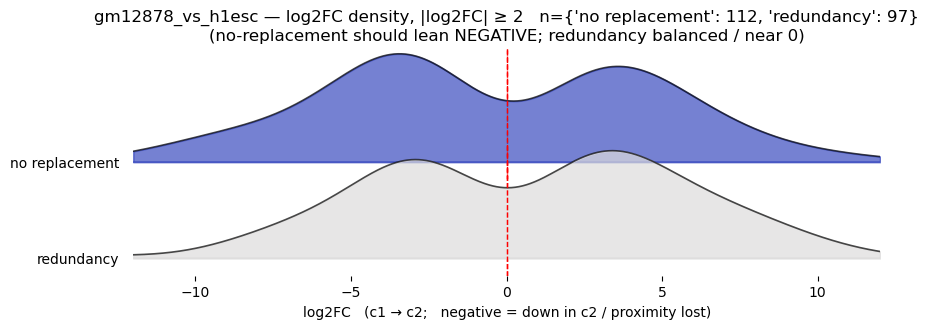

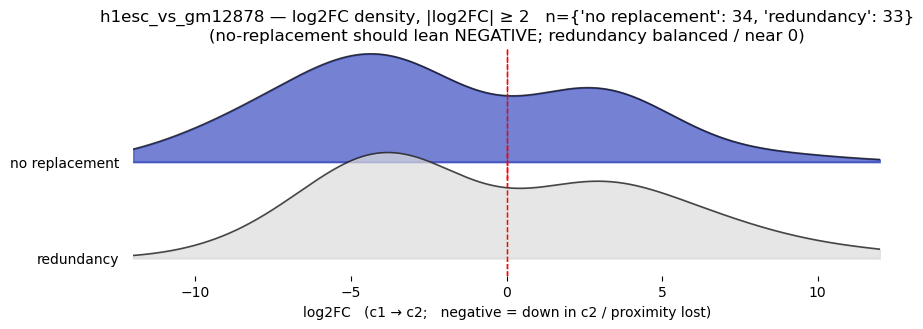

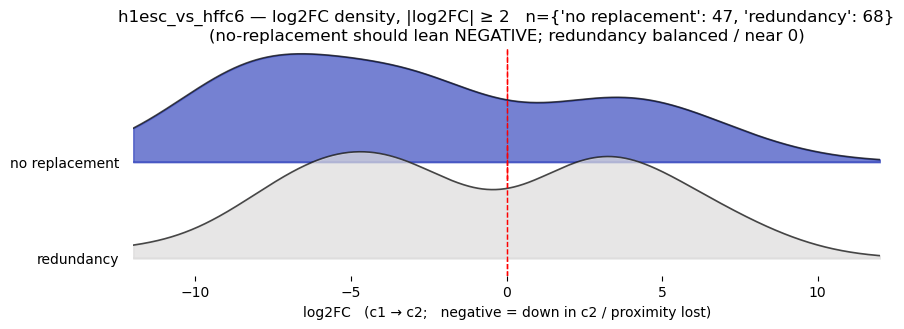

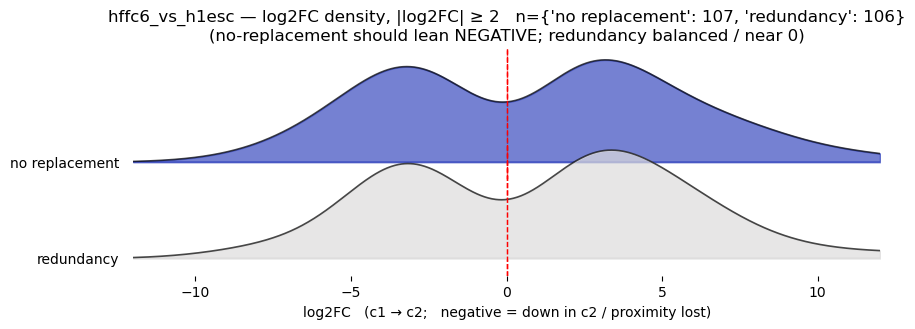

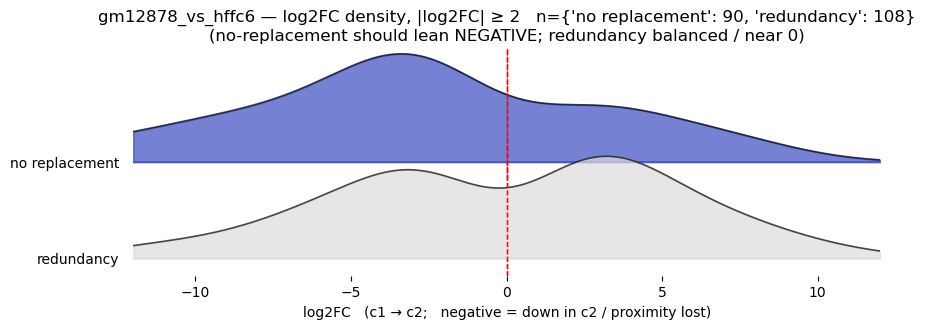

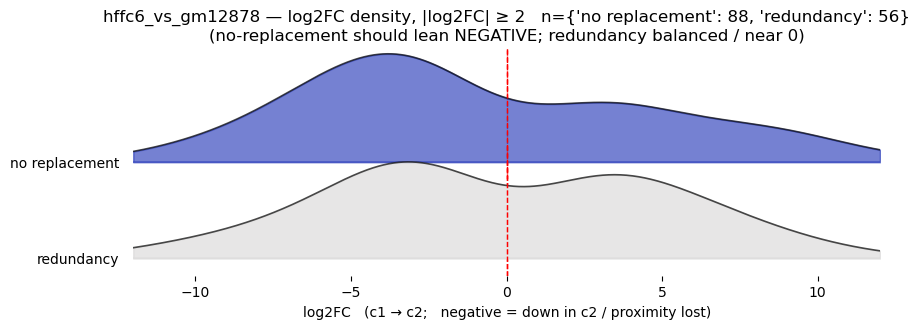

In [6]:
# --- ridge / density plot of SIGNED log2FC, significant changes only (|log2FC| >= LFC_ABS_MIN).
#     The bulk of genes sit at ~0 and drown the signal in the full distribution; restricting to
#     genes that actually moved exposes the DIRECTION: no-replacement should lean NEGATIVE
#     (lost its only close enhancer -> down in c2), redundancy should be balanced / near 0.
#     Set LFC_ABS_MIN = 0 to include everything (then the 0-bulk dominates, like the ECDF).
import joypy
from matplotlib import cm

LFC_ABS_MIN = 2.0
for comparison, m in joined.items():
    sub = m.assign(group=np.where(m.is_redundancy, 'redundancy',
                          np.where(m.is_nonredundant_switcher, 'no replacement', None)))
    sub = sub.dropna(subset=['group'])
    sub = sub[sub['log2FoldChange'].abs() >= LFC_ABS_MIN]
    plot_data = {g: gg['log2FoldChange'].values for g, gg in sub.groupby('group') if len(gg) >= 5}
    if not plot_data:
        print(f"{comparison}: too few genes with |log2FC| >= {LFC_ABS_MIN:g}")
        continue
    counts = {g: len(v) for g, v in plot_data.items()}
    fig, axes = joypy.joyplot(
        plot_data, figsize=(9, 3.2), colormap=cm.coolwarm,
        overlap=0.5, linewidth=1.2, alpha=0.7, legend=False, x_range=[-12, 12],
        title=f"{comparison} — log2FC density, |log2FC| ≥ {LFC_ABS_MIN:g}   n={counts}\n"
              "(no-replacement should lean NEGATIVE; redundancy balanced / near 0)",
    )
    for ax in axes:
        ax.axvline(0, color='red', lw=1, ls='--')
    plt.xlabel("log2FC   (c1 → c2;   negative = down in c2 / proximity lost)")
    plt.savefig(os.path.join(FIGS, f"exp6_ridge_log2fc_{comparison}.png"), dpi=150, bbox_inches='tight')
    plt.show()